Original dimensions: 643 x 642

2x2 shear matrix:
[[ 1.  -0.3]
 [ 0.   1. ]]

New dimensions: 836 x 642

2x3 affine shear matrix:
[[  1.   -0.3 192.6]
 [  0.    1.    0. ]]

Saved: task3_fixed_barcode.jpg


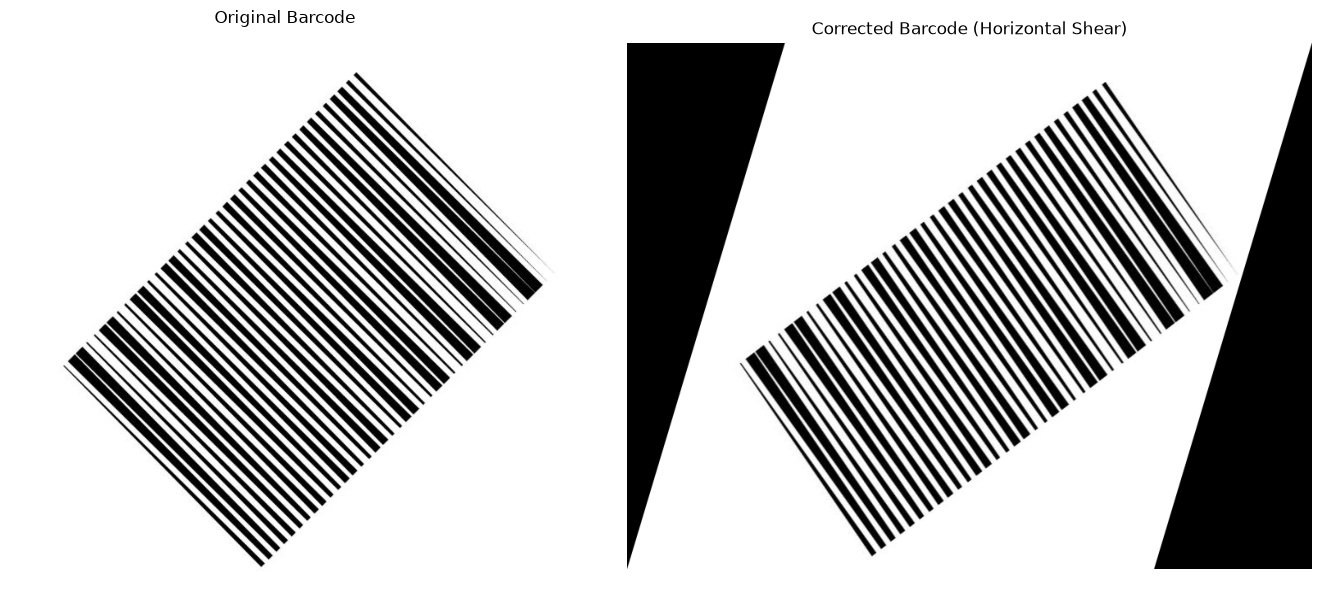

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
image_path = "barcode.jpg"
output_path = "task3_fixed_barcode.jpg"

# ---------------------------------------------------------
# Read image
# ---------------------------------------------------------
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not find image: {image_path}")

h, w = img.shape[:2]

print("Original dimensions:", w, "x", h)

# ---------------------------------------------------------
# Horizontal shear correction
# ---------------------------------------------------------
shear = -0.30

# 2x2 shear matrix
Sh = np.array([
    [1.0, shear],
    [0.0, 1.0]
], dtype=np.float32)

print("\n2x2 shear matrix:")
print(Sh)

# ---------------------------------------------------------
# Calculate the new width
# ---------------------------------------------------------
min_x = min(0.0, shear * h)
max_x = max(float(w), w + shear * h)

new_w = int(np.ceil(max_x - min_x))

print("\nNew dimensions:", new_w, "x", h)

# ---------------------------------------------------------
# 2x3 affine transformation matrix
# ---------------------------------------------------------
M = np.array([
    [1.0, shear, -min_x],
    [0.0, 1.0, 0.0]
], dtype=np.float32)

print("\n2x3 affine shear matrix:")
print(M)

# ---------------------------------------------------------
# Apply shear transformation
# ---------------------------------------------------------
result = cv2.warpAffine(
    img,
    M,
    (new_w, h),
    cv2.INTER_CUBIC
)

# ---------------------------------------------------------
# Save corrected barcode
# ---------------------------------------------------------
cv2.imwrite(output_path, result)

print("\nSaved:", output_path)

# ---------------------------------------------------------
# Convert BGR to RGB for Matplotlib
# ---------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Display original and corrected images
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Barcode")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title("Corrected Barcode (Horizontal Shear)")
plt.axis("off")

plt.tight_layout()
plt.show()
